In [1]:
import pandas as pd
import numpy as np
import os
import math
import matplotlib.pyplot as plt
import openpyxl
from DaySim import DaysimSummary

In [2]:
#file ="Z:/projects/temp_va/temp_chattanooga/model_outputs/_person_2.dat"
#perdata = pd.read_csv(file, sep = '\t') 

In [3]:
output_file = "Z:/projects/temp_va/temp_chattanooga/model_outputs/DaySim_summaries_base_year.csv"


In [4]:
report = DaysimSummary()

runVehAvailability = True, loading data...
runTripMode = True, loading data...
runTourMode = True, loading data...
runTripDestination = True, loading data...
runTourDestination = True, loading data...
runTripTOD = True, loading data...
runTourTOD = True, loading data...


In [5]:
def _safe(callable_obj, *args, **kwargs):
    try:
        return callable_obj(*args, **kwargs)
    except Exception as e:
        name = getattr(callable_obj, "__name__", str(callable_obj))
        print(f"Skipped {name} args={args} kwargs={kwargs}: {e}")
        return None

vehavail_drivers = _safe(report.summary_vehavail, "hh16cat")
if vehavail_drivers is None:
    vehavail_drivers = _safe(report.summary_vehavail, "hhcat16")

tables = {
    # Vehicle availability
    "Vehavail County": _safe(report.summary_vehavail, "hhcounty"),
    "Vehavail Income": _safe(report.summary_vehavail, "inccat"),
    "Vehavail Drivers": vehavail_drivers,

    # Work/School location
    "Work Trip Length": _safe(report.summary_wrkschloc_trip_length, "wrkr"),
    "Work Trip Duration": _safe(report.summary_wrkschloc_trip_duration, "wrkr"),
    "Work County Flow": _safe(report.summary_wrkschloc_county_flow, "wrkr"),
    "Work-At-Home": _safe(report.summary_wrkschloc_at_home, "wfh"),
    "School Trip Length": _safe(report.summary_wrkschloc_trip_length, "stud"),
    "School Trip Duration": _safe(report.summary_wrkschloc_trip_duration, "stud"),
    "School County Flow": _safe(report.summary_wrkschloc_county_flow, "stud"),
    "School-At-Home": _safe(report.summary_wrkschloc_at_home, "sfh"),

    # Mode
    "Work Trip Mode": _safe(report.summary_trip_mode, purpose=1),       
    "Work Tour Mode": _safe(report.summary_tour_mode, purpose=1),

    # Destination
    "Trip Length": _safe(report.summary_trip_destination, "distcat"),
    "Trip Duration": _safe(report.summary_trip_destination, "timecat"),
    "Tour Length": _safe(report.summary_tour_destination, "distcat"),
    "Tour Duration": _safe(report.summary_tour_destination, "timecat"),
    "Work Tour County Flow": _safe(report.summary_tour_destination_county_flow, purpose=1),

    # Trip time of day
    "Trip Arrive Time (Outbound)": _safe(report.summary_trip_tod, "arrtimecat", filter_by_var="arrflag"),
    "Trip Depart Time (Return)": _safe(report.summary_trip_tod, "deptimecat", filter_by_var="depflag"),
    "Trip Stop Duration": _safe(report.summary_trip_tod, "durdestcat", filter_by_var="durflag"),
    "Trip Arrive Time (All)": _safe(report.summary_trip_tod, "arrtimecat", filter_by_var=False),
    "Trip Depart Time (All)": _safe(report.summary_trip_tod, "deptimecat", filter_by_var=False),

    # Tour time of day
    "Tour Arrive Time (All)": _safe(report.summary_tour_tod, "arrtimecat"),
    "Tour Depart Time (All)": _safe(report.summary_tour_tod, "deptimecat"),
    "Tour Duration (All)": _safe(report.summary_tour_tod, "durdestcat"),
    "School Tour Arrive by Person Type": _safe(report.summary_tour_tod_purpose, "arrtimecat", purpose=2),
    "School Tour Depart by Person Type": _safe(report.summary_tour_tod_purpose, "deptimecat", purpose=2),

    # Person day pattern
    "Num of Tours": _safe(report.summary_day_pattern_num_of_tours),
    "Tour/Stop Combinations": _safe(report.summary_day_pattern_tour_stops),
    "Tour Stops by Purpose": _safe(report.summary_day_pattern_tour_stops_by_purpose, purpose="wktostp"),
    "Tours by Purpose": _safe(report.summary_day_pattern_tours_by_purpose, purpose="wktopt"),
    "Subtours": _safe(report.summary_day_pattern_subtours),
    "Subtours by Purpose": _safe(report.summary_day_pattern_subtours_by_purpose),
    "Stops by Tour Purpose (Total)": _safe(report.summary_day_pattern_stops_by_tour_purpose, "stopscat"),
    "Stops by Tour Purpose (Outbound)": _safe(report.summary_day_pattern_stops_by_tour_purpose, "h1stopscat"),
    "Stops by Tour Purpose (Return)": _safe(report.summary_day_pattern_stops_by_tour_purpose, "h2stopscat"),
    "Tour Purpose by Person Type": _safe(report.summary_day_pattern_tours_by_tour_purpose, "pptyp"),
    "Tour Purpose by Income": _safe(report.summary_day_pattern_tours_by_tour_purpose, "inccat"),
    "Tour Purpose by Vehicle Sufficiency": _safe(report.summary_day_pattern_tours_by_tour_purpose, "vehsuf"),
    "Tour Purpose by County": _safe(report.summary_day_pattern_tours_by_tour_purpose, "hhcounty"),
    "Stops Purpose Agg by Person Type": _safe(report.summary_day_pattern_stops_by_stop_purpose_agg, "pptyp"),
    "Stops Purpose Agg by Income": _safe(report.summary_day_pattern_stops_by_stop_purpose_agg, "inccat"),
    "Stops Purpose Agg by Vehicle Sufficiency": _safe(report.summary_day_pattern_stops_by_stop_purpose_agg, "vehsuf"),
    "Stops Purpose Agg by County": _safe(report.summary_day_pattern_stops_by_stop_purpose_agg, "hhcounty"),
    "Trip Purpose by Person Type": _safe(report.summary_day_pattern_trips_by_destination_purpose, "pptyp"),
    "Trip Purpose by Income": _safe(report.summary_day_pattern_trips_by_destination_purpose, "inccat"),
    "Trip Purpose by Vehicle Sufficiency": _safe(report.summary_day_pattern_trips_by_destination_purpose, "vehsuf"),
    "Trip Purpose by County": _safe(report.summary_day_pattern_trips_by_destination_purpose, "ocounty"),

    
}

tables = {k: v for k, v in tables.items() if v is not None}

Skipped summary_wrkschloc_trip_length args=('wrkr',) kwargs={}: 'DaysimSummary' object has no attribute 'perdata_wrkschloc'
Skipped summary_wrkschloc_trip_duration args=('wrkr',) kwargs={}: 'DaysimSummary' object has no attribute 'perdata_wrkschloc'
Skipped summary_wrkschloc_county_flow args=('wrkr',) kwargs={}: 'DaysimSummary' object has no attribute 'perdata_wrkschloc'
Skipped summary_wrkschloc_at_home args=('wfh',) kwargs={}: 'DaysimSummary' object has no attribute 'perdata_wrkschloc'
Skipped summary_wrkschloc_trip_length args=('stud',) kwargs={}: 'DaysimSummary' object has no attribute 'perdata_wrkschloc'
Skipped summary_wrkschloc_trip_duration args=('stud',) kwargs={}: 'DaysimSummary' object has no attribute 'perdata_wrkschloc'
Skipped summary_wrkschloc_county_flow args=('stud',) kwargs={}: 'DaysimSummary' object has no attribute 'perdata_wrkschloc'
Skipped summary_wrkschloc_at_home args=('sfh',) kwargs={}: 'DaysimSummary' object has no attribute 'perdata_wrkschloc'
Skipped summar

In [6]:
def _normalize_table_axes(tab):
    t = tab.copy()

    if isinstance(t, pd.Series):
        t = t.to_frame(name="value")

    # capture original axis names
    idx_names = list(t.index.names) if isinstance(t.index, pd.MultiIndex) else [t.index.name]
    col_names = list(t.columns.names) if isinstance(t.columns, pd.MultiIndex) else [t.columns.name]

    idx_names = [n if n not in [None, ""] else f"index_level_{i+1}" for i, n in enumerate(idx_names)]
    col_names = [n if n not in [None, ""] else f"column_level_{i+1}" for i, n in enumerate(col_names)]

    # semantic dimension names
    dim_2_name = "|".join(map(str, idx_names))
    dim_1_name = "|".join(map(str, col_names))

    # flatten index categories
    if isinstance(t.index, pd.MultiIndex):
        t.index = pd.Index(
            [
                "|".join(str(v) for v in x if v is not None and str(v) != "")
                for x in t.index.to_flat_index()
            ],
            name=dim_2_name,
        )
    else:
        t.index = t.index.rename(dim_2_name)

    # flatten column categories
    if isinstance(t.columns, pd.MultiIndex):
        t.columns = [
            "|".join(str(v) for v in col if v is not None and str(v) != "")
            for col in t.columns.to_flat_index()
        ]
    else:
        t.columns = t.columns.astype(str)

    # store semantic dimension names
    t.attrs["dimension_1"] = dim_1_name
    t.attrs["dimension_2"] = dim_2_name

    return t



In [7]:

def table_to_long(tab, table_name):
    out = tab.copy().reset_index()

    dim_1_name = tab.attrs.get("dimension_1", "dimension_1")

    # detect the index column created by reset_index()
    dim2_col = out.columns[0]

    # standardize category column name for melt
    out = out.rename(columns={dim2_col: "category"})

    long_df = out.melt(
        id_vars=["category"],
        var_name="dimension_1_category",
        value_name="value",
    )

    long_df.insert(1, "dimension_1", dim_1_name)

    value_num = pd.to_numeric(long_df["value"], errors="coerce")

    idx_total = value_num.groupby(long_df["category"]).transform("sum")
    cat_total = value_num.groupby(long_df["dimension_1_category"]).transform("sum")

    long_df["pct_across_category"] = np.where(idx_total != 0, value_num / idx_total * 100, np.nan)
    long_df["pct_across_index"] = np.where(cat_total != 0, value_num / cat_total * 100, np.nan)

    total = value_num.sum()
    long_df["percent"] = np.where(total != 0, value_num / total * 100, np.nan)

    long_df.insert(0, "table_name", table_name)
    return long_df


tables = {name: _normalize_table_axes(tab) for name, tab in tables.items()}



In [8]:
output_df = pd.concat([table_to_long(tab, name) for name, tab in tables.items()], ignore_index=True)

In [9]:
output_df.head()

,table_name,category,dimension_1,dimension_1_category,value,pct_across_category,pct_across_index,percent
0,Vehavail County,1,hhvehcat,0,20512.0,13.038807,91.063263,10.321126
1,Vehavail County,2,hhvehcat,0,1166.0,4.607421,5.176471,0.586702
2,Vehavail County,3,hhvehcat,0,130.0,7.178355,0.577137,0.065413
3,Vehavail County,4,hhvehcat,0,717.0,5.012233,3.183130,0.360776
4,Vehavail County,1,hhvehcat,1,47833.0,30.405874,79.130823,24.068371


In [10]:
output_df.to_csv(output_file, index=False)

## Vehicle Availability

In [11]:
# by household income
report.summary_vehavail("inccat")




hhvehcat,0,1,2,3,4
inccat,,,,,
0K-15K,7096.0,10065.0,2002.0,339.0,93.0
15K-50K,4966.0,29755.0,18505.0,6790.0,4219.0
50K-75K,569.0,6451.0,14966.0,6842.0,4415.0
>75K,1704.0,7351.0,26951.0,16334.0,13496.0


In [12]:
# by county
report.summary_vehavail("hhcounty")



hhvehcat,0,1,2,3,4
hhcounty,,,,,
1,20512.0,47833.0,49051.0,23101.0,16818.0
2,1166.0,7271.0,8747.0,4629.0,3494.0
3,130.0,805.0,497.0,240.0,139.0
4,717.0,4539.0,4795.0,2438.0,1816.0


In [13]:
# by household drivers
report.summary_vehavail("hh16cat")

hhvehcat,0,1,2,3,4
hh16cat,,,,,
1,17456.0,46263.0,8947.0,2150.0,2099.0
2,3916.0,12088.0,47128.0,17078.0,9320.0
3,566.0,1391.0,6259.0,7054.0,4177.0
4,587.0,706.0,756.0,4126.0,6671.0


## Work/School Location

In [14]:
# work trip length
df = report.summary_wrkschloc_trip_length("wrkr")
df.columns = df.columns.astype(str)
df = df.reset_index()
plt.bar(x=df['wrkdistcat'],height=(df['FT']+df['PT']+df['NotFTPT']))

AttributeError: 'DaysimSummary' object has no attribute 'perdata_wrkschloc'

<BarContainer object of 68 artists>

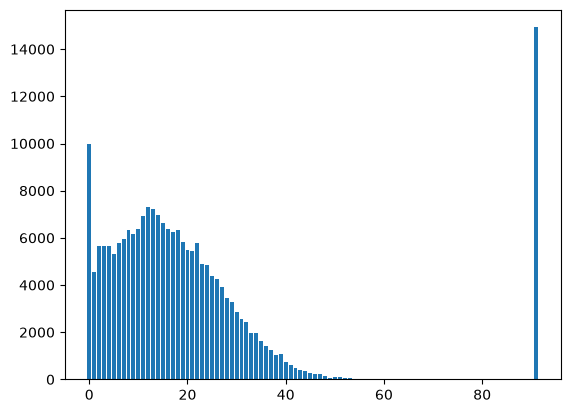

In [ ]:
# work trip duration
df = report.summary_wrkschloc_trip_duration("wrkr")
df.columns = df.columns.astype(str)
df = df.reset_index()
plt.bar(x=df['wrktimecat'],height=(df['FT']+df['PT']+df['NotFTPT']))

In [ ]:
# work trip county flow
report.summary_wrkschloc_county_flow("wrkr")

pwcounty,1.0,2.0,3.0,4.0,13.0
hhcounty,,,,,
1,148636.0,5761.0,294.0,1707.0,8016.0
2,16264.0,6826.0,39.0,943.0,5033.0
3,1240.0,66.0,156.0,72.0,112.0
4,9514.0,1595.0,58.0,2125.0,1763.0


In [ ]:
# work from home
report.summary_wrkschloc_at_home("wfh")

wrkrtyp,FT,PT,NotFTPT
hhcounty,,,
1,4695.0,1751.0,235.0
2,722.0,329.0,26.0
3,50.0,21.0,2.0
4,370.0,201.0,9.0


<BarContainer object of 46 artists>

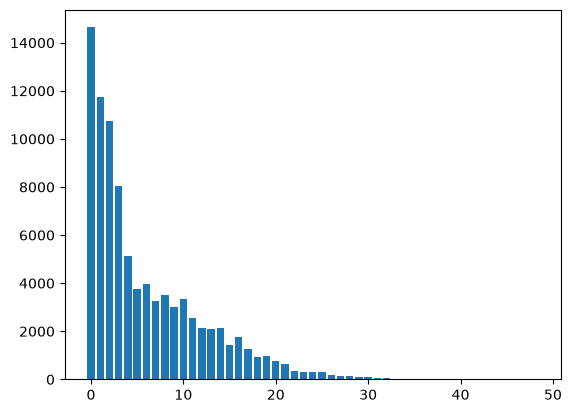

In [ ]:
# school trip length
df = report.summary_wrkschloc_trip_length("stud")
df.columns = df.columns.astype(str)
df = df.reset_index()
plt.bar(x=df['schdistcat'],height=(df['Ch515']+df['Stu16']+df['UniStu']))

<BarContainer object of 62 artists>

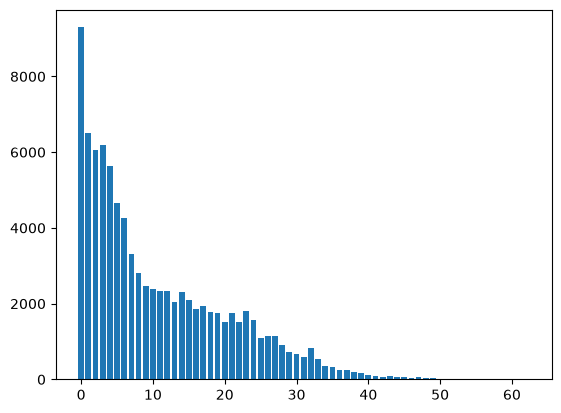

In [ ]:
# school trip duration
df = report.summary_wrkschloc_trip_duration("stud")
df.columns = df.columns.astype(str)
df = df.reset_index()
plt.bar(x=df['schtimecat'],height=(df['Ch515']+df['Stu16']+df['UniStu']))

In [ ]:
# school trip county flow
report.summary_wrkschloc_county_flow("stud")


pscounty,1.0,2.0,3.0,4.0
hhcounty,,,,
1,64833.0,1481.0,322.0,713.0
2,6128.0,7551.0,66.0,748.0
3,373.0,11.0,56.0,58.0
4,3263.0,846.0,128.0,3497.0


In [ ]:
# school at home
report.summary_wrkschloc_at_home("sfh")

stutyp,Ch515,Stu16,UniStu
hhcounty,,,
1,4149.0,253.0,1002.0
2,666.0,38.0,50.0
3,8.0,0.0,1.0
4,284.0,22.0,19.0


## Trip Mode

In [ ]:
# Work
report.summary_trip_mode(purpose=1) 
# 1-Work 2-School 3-Escort 4-Personal_Business 5-Shop 6-Meal 7-Social&Recreational 8-Workbased

tourmode,Drive Alone,Shared Ride 2,Shared Ride 3+,Drive-Transit,Walk-Transit,Bike,Walk,School Bus
tripmode,,,,,,,,
Drive Alone,349488.0,49603.0,19210.0,1340.0,19.0,0.0,0.0,0.0
Shared Ride 2,0.0,55202.0,9809.0,0.0,58.0,0.0,0.0,0.0
Shared Ride 3+,0.0,0.0,35249.0,0.0,15.0,0.0,0.0,0.0
Transit-local bus,0.0,0.0,0.0,1002.0,764.0,0.0,0.0,0.0
Transit-light rail,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Transit-premium bus,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Transit-commuter rail,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Transit-ferry,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
School Bus,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Tour Mode

In [ ]:
# Work
report.summary_tour_mode(purpose=1)
# 1-Work 2-School 3-Escort 4-Personal_Business 5-Shop 6-Meal 7-Social&Recreational 8-Workbased



vehcat,0-Veh HHs,>0-Veh HHs
tourmode,,
Drive Alone,0.0,120218.0
Shared Ride 2,2083.0,26547.0
Shared Ride 3+,1158.0,15246.0
Drive-Transit,0.0,501.0
Walk-Transit,165.0,265.0
Bike,130.0,173.0
Walk,525.0,870.0
School Bus,0.0,0.0


## Trip Destination

<BarContainer object of 54 artists>

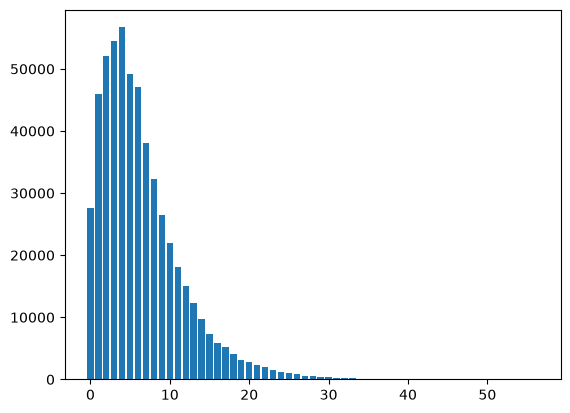

In [ ]:
# trip length by trip purpose
df = report.summary_trip_destination("distcat").reset_index()
plt.bar(x=df['distcat'],height=df[0]) 
# 0-non/home  1-Work 2-School 3-Escort 4-Personal_Business 5-Shop 6-Meal 7-Social&Recreational 10-change mode inserted purpose



<BarContainer object of 90 artists>

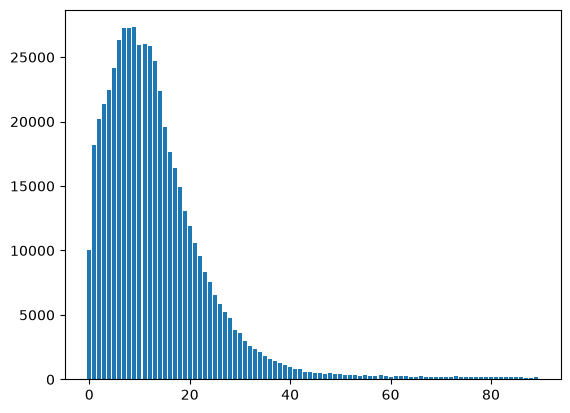

In [ ]:
# trip duration by trip purpose
df = report.summary_trip_destination("timecat").reset_index()
plt.bar(x=df['timecat'],height=df[0])
# 0-non/home  1-Work 2-School 3-Escort 4-Personal_Business 5-Shop 6-Meal 7-Social&Recreational 10-change mode inserted purpose



## Tour Destination

<BarContainer object of 52 artists>

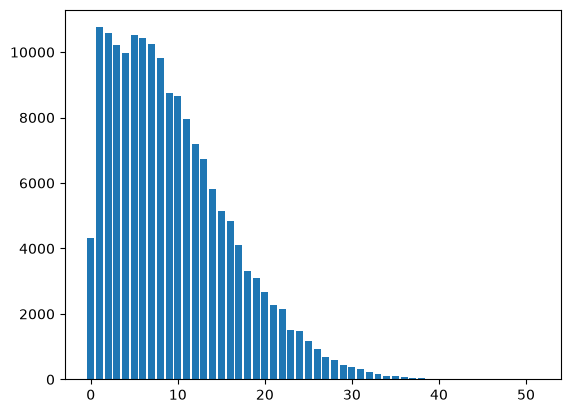

In [ ]:
# tour length by tour purpose
df = report.summary_tour_destination("distcat").reset_index()
plt.bar(x=df['distcat'],height=df[1])
# 1-Work 2-School 3-Escort 4-Personal_Business 5-Shop 6-Meal 7-Social&Recreational 8-Workbased

<BarContainer object of 67 artists>

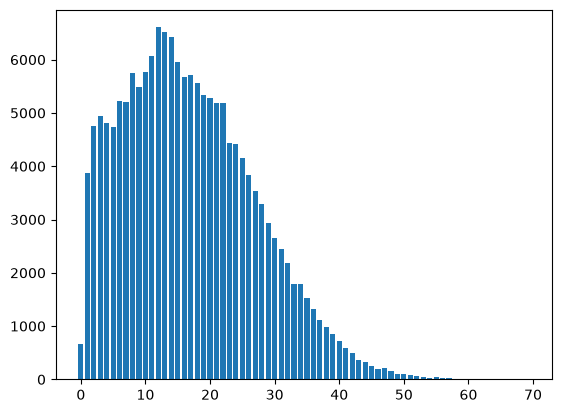

In [ ]:
# tour duration by tour purpose
df = report.summary_tour_destination("timecat").reset_index()
plt.bar(x=df['timecat'],height=df[1])
# 1-Work 2-School 3-Escort 4-Personal_Business 5-Shop 6-Meal 7-Social&Recreational 8-Workbased

In [ ]:
# tour county flow by tour purpose
report.summary_tour_destination_county_flow(purpose=1)
# 1-Work 2-School 3-Escort 4-Personal_Business 5-Shop 6-Meal 7-Social&Recreational 8-Workbased





dcounty,1,2,3,4
ocounty,,,,
1,126988.0,5368.0,268.0,1654.0
2,14637.0,5209.0,34.0,929.0
3,1083.0,57.0,71.0,73.0
4,8550.0,1468.0,54.0,1438.0


## Trip Time of Day

<BarContainer object of 43 artists>

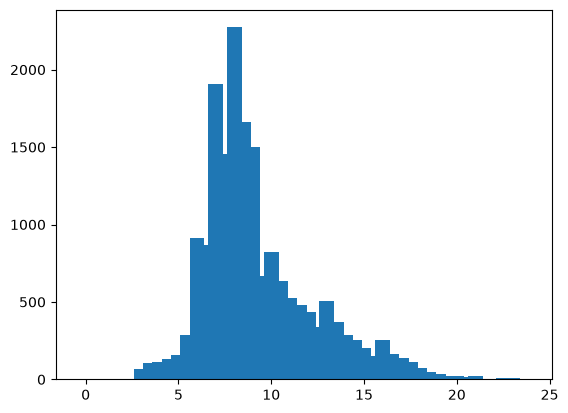

In [ ]:
# Trip arrival time at stop location - outbound (first) half-tour
df = report.summary_trip_tod("arrtimecat",filter_by_var="arrflag").reset_index()
plt.bar(x=df['arrtimecat'],height=df[1])
# 1-Work 2-School 3-Escort 4-Personal_Business 5-Shop 6-Meal 7-Social&Recreational 10-change mode inserted purpose




<BarContainer object of 42 artists>

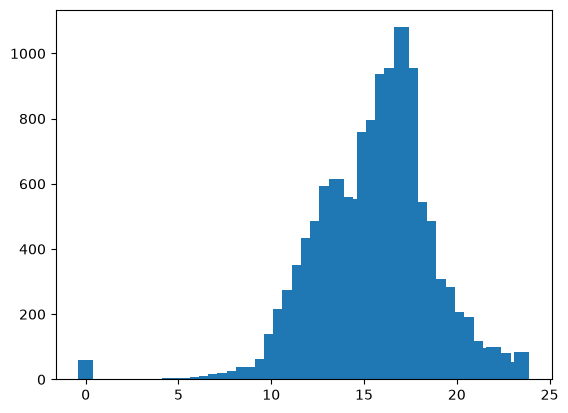

In [ ]:
# Trip departure time at stop location - return (second) half-tour
df = report.summary_trip_tod("deptimecat",filter_by_var="depflag").reset_index()
plt.bar(x=df['deptimecat'],height=df[1])
# 1-Work 2-School 3-Escort 4-Personal_Business 5-Shop 6-Meal 7-Social&Recreational 10-change mode inserted purpose



<BarContainer object of 25 artists>

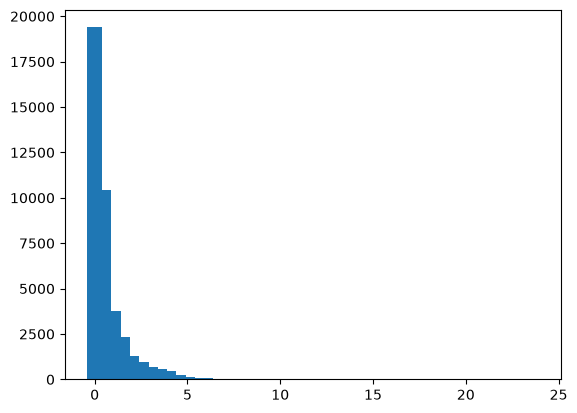

In [ ]:
# Duration at stop location - both half-tours
df = report.summary_trip_tod("durdestcat",filter_by_var="durflag").reset_index()
plt.bar(x=df['durdestcat'],height=df[1])
# 1-Work 2-School 3-Escort 4-Personal_Business 5-Shop 6-Meal 7-Social&Recreational 10-change mode inserted purpose



<BarContainer object of 43 artists>

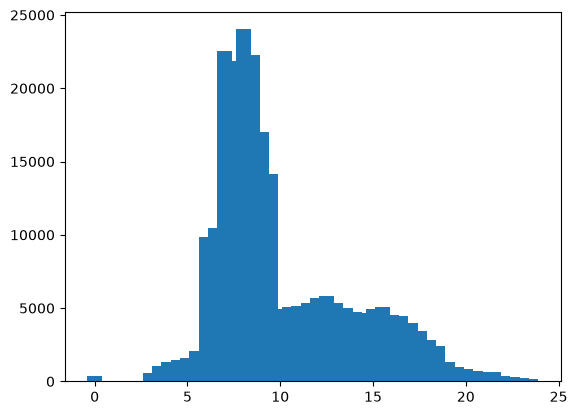

In [ ]:
# Trip arrival time All
df = report.summary_trip_tod("arrtimecat",filter_by_var=False).reset_index()
plt.bar(x=df['arrtimecat'],height=df[1])
# 1-Work 2-School 3-Escort 4-Personal_Business 5-Shop 6-Meal 7-Social&Recreational 10-change mode inserted purpose



<BarContainer object of 43 artists>

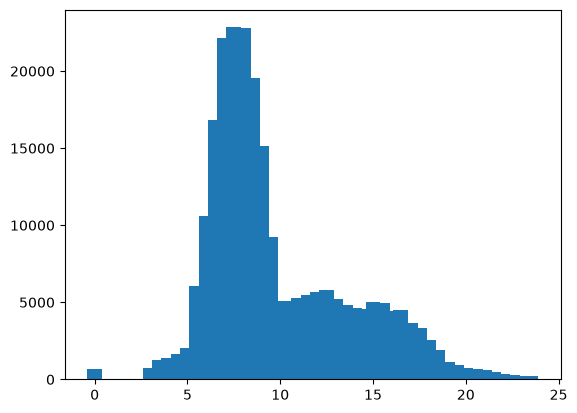

In [ ]:
# Trip departure time All
df = report.summary_trip_tod("deptimecat",filter_by_var=False).reset_index()
plt.bar(x=df['deptimecat'],height=df[1])
# 1-Work 2-School 3-Escort 4-Personal_Business 5-Shop 6-Meal 7-Social&Recreational 10-change mode inserted purpose

## Tour Time of Day

<BarContainer object of 43 artists>

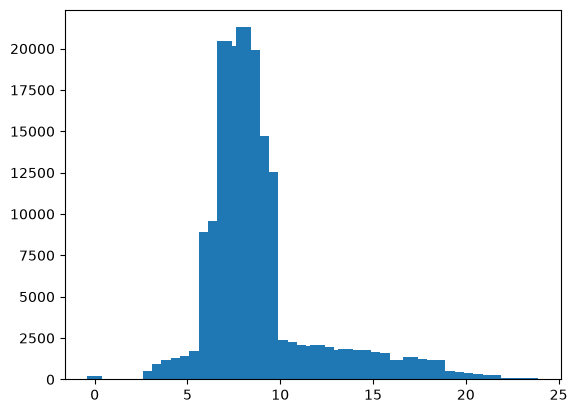

In [ ]:
# arrival time all trip purposes
df = report.summary_tour_tod("arrtimecat").reset_index()
plt.bar(x=df['arrtimecat'],height=df[1]) 
# 1 Work 2 School 3 Other 4 Workbased



<BarContainer object of 43 artists>

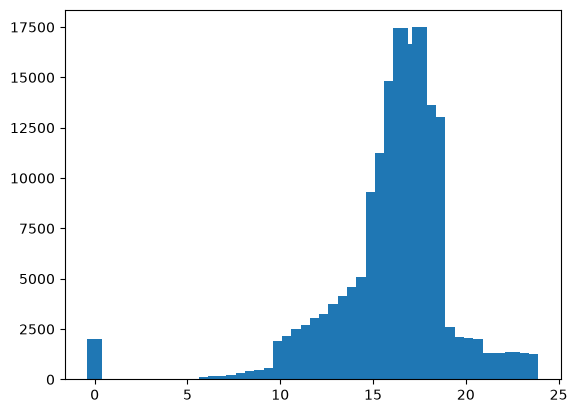

In [ ]:
# departure time all trip purposes
df = report.summary_tour_tod("deptimecat").reset_index()
plt.bar(x=df['deptimecat'],height=df[1]) 
# 1 Work 2 School 3 Other 4 Workbased

<BarContainer object of 39 artists>

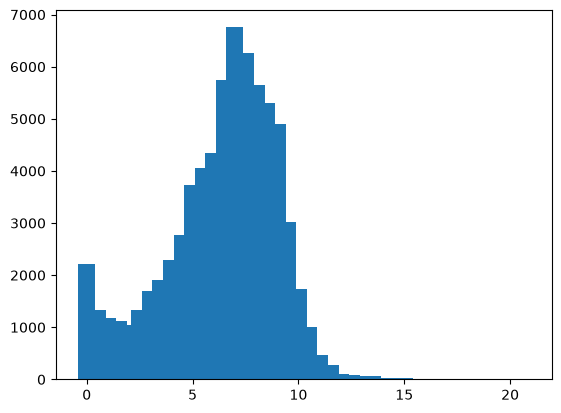

In [ ]:
# duration all trip purposes
df = report.summary_tour_tod("durdestcat").reset_index()
plt.bar(x=df['durdestcat'],height=df[2]) 
# 1 Work 2 School 3 Other 4 Workbased



In [ ]:
# arrival time by trip purpose by person type
report.summary_tour_tod_purpose("arrtimecat", purpose=2).reset_index()
# purpose: 1 Work 2 School 3 Other 4 Workbased
# columns: 1-FT 2-PT 3-Retired 4-Nonworker 5-UnivStud 6-Stud16+ 7-Stud5-15 8-Child<5


pptyp,arrtimecat,1,2,3,4,5,6,7,8
0,4.5,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,5.5,1.0,0.0,0.0,0.0,1.0,19.0,74.0,1.0
2,6.0,29.0,0.0,0.0,0.0,199.0,741.0,3930.0,165.0
3,6.5,27.0,0.0,0.0,0.0,222.0,658.0,3896.0,190.0
4,7.0,67.0,0.0,0.0,0.0,467.0,1116.0,7769.0,387.0
5,7.5,75.0,0.0,0.0,0.0,541.0,952.0,7098.0,399.0
6,8.0,94.0,0.0,0.0,0.0,746.0,962.0,8059.0,451.0
7,8.5,148.0,0.0,0.0,0.0,819.0,813.0,7155.0,394.0
8,9.0,95.0,0.0,0.0,0.0,665.0,465.0,4947.0,281.0
9,9.5,117.0,0.0,0.0,0.0,778.0,342.0,4377.0,269.0


In [ ]:
# departure time by trip purpose by person type
report.summary_tour_tod_purpose("deptimecat", purpose=2).reset_index()
# purpose: 1 Work 2 School 3 Other 4 Workbased
# columns: 1-FT 2-PT 3-Retired 4-Nonworker 5-UnivStud 6-Stud16+ 7-Stud5-15 8-Child<5



pptyp,deptimecat,1,2,3,4,5,6,7,8
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,6.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,6.5,0.0,0.0,0.0,0.0,0.0,4.0,4.0,0.0
3,7.0,1.0,0.0,0.0,0.0,24.0,75.0,272.0,0.0
4,7.5,1.0,0.0,0.0,0.0,24.0,68.0,247.0,0.0
5,8.0,0.0,0.0,0.0,0.0,51.0,41.0,295.0,1.0
6,8.5,3.0,0.0,0.0,0.0,45.0,40.0,295.0,1.0
7,9.0,4.0,0.0,0.0,0.0,54.0,28.0,379.0,1.0
8,9.5,4.0,0.0,0.0,0.0,66.0,39.0,422.0,2.0
9,10.0,2.0,0.0,0.0,0.0,91.0,32.0,489.0,2.0


## Person Day Pattern

In [ ]:
# number of tours by person type
report.summary_day_pattern_num_of_tours()
# columns: 1-FT 2-PT 3-Retired 4-Nonworker 5-UnivStud 6-Stud16+ 7-Stud5-15 8-Child<5



pptyp,1,2,3,4,5,6,7,8
tottours,,,,,,,,
0,21621.0,1997.0,22919.0,16619.0,8961.0,2657.0,1818.0,9754.0
1,108212.0,12429.0,30239.0,36935.0,8325.0,5291.0,37264.0,13591.0
2,36140.0,9369.0,11492.0,17375.0,3104.0,1784.0,15842.0,4313.0
3,7868.0,3926.0,3571.0,8353.0,932.0,356.0,3740.0,1331.0


In [ ]:
# tour/stop combinations by person type
report.summary_day_pattern_tour_stops()
# columns: 1-FT 2-PT 3-Retired 4-Nonworker 5-UnivStud 6-Stud16+ 7-Stud5-15 8-Child<5
# index: tours/stops
# 0 0/0
# 1 1/0
# 2 1/1
# 3 1/2
# 4 1/3+
# 5 2/0
# 6 2/1
# 7 2/2
# 8 2/3+
# 9 3+/0
# 10 3+/1
# 11 3+/2
# 12 3+/3+

pptyp,1,2,3,4,5,6,7,8
tourstop,,,,,,,,
0,21621.0,1997.0,22919.0,16619.0,8961.0,2657.0,1818.0,9754.0
1,17722.0,3.0,8330.0,7634.0,3616.0,2196.0,5931.0,3798.0
2,32079.0,215.0,9751.0,11180.0,2893.0,1610.0,11668.0,4379.0
3,30213.0,2024.0,8740.0,12549.0,1349.0,1008.0,10621.0,3568.0
4,28198.0,10187.0,3418.0,5572.0,467.0,477.0,9044.0,1846.0
5,5017.0,45.0,2603.0,2917.0,982.0,487.0,2579.0,906.0
6,10852.0,536.0,3692.0,4903.0,1245.0,609.0,5155.0,1315.0
7,11456.0,2739.0,3756.0,6330.0,648.0,458.0,4818.0,1354.0
8,8815.0,6049.0,1441.0,3225.0,229.0,230.0,3290.0,738.0


In [ ]:
# tour/stop combinations by purpose by person type
report.summary_day_pattern_tour_stops_by_purpose(purpose="wktostp")
# purpose: "wktostp", "sctostp", "estostp", "pbtostp", "shtostp", "mlstops", "sotostp"
# columns: 1-FT 2-PT 3-Retired 4-Nonworker 5-UnivStud 6-Stud16+ 7-Stud5-15 8-Child<5
# index: tours/stops
# 1 0/0
# 2 0/1+
# 3 1+/0
# 4 1+/1+



pptyp,1,2,3,4,5,6,7,8
wktostp,,,,,,,,
1,37308.0,9170.0,68221.0,79282.0,19592.0,8929.0,58664.0,28989.0
2,1155.0,0.0,0.0,0.0,607.0,686.0,0.0,0.0
3,90327.0,14227.0,0.0,0.0,806.0,327.0,0.0,0.0
4,45051.0,4324.0,0.0,0.0,317.0,146.0,0.0,0.0


In [ ]:
# tours by purpose by person type
report.summary_day_pattern_tours_by_purpose(purpose="wktopt")
# purpose: "wktopt", "sctopt", "estopt", "pbtopt", "shtopt", "mltopt", "sotopt"
# columns: 1-FT 2-PT 3-Retired 4-Nonworker 5-UnivStud 6-Stud16+ 7-Stud5-15 8-Child<5
# index: 0,1,2,3+



pptyp,1,2,3,4,5,6,7,8
wktopt,,,,,,,,
0,38463.0,9170.0,68221.0,79282.0,20199.0,9615.0,58664.0,28989.0
1,125298.0,16908.0,0.0,0.0,1053.0,438.0,0.0,0.0
2,9621.0,1577.0,0.0,0.0,68.0,34.0,0.0,0.0
3,459.0,66.0,0.0,0.0,2.0,1.0,0.0,0.0


In [ ]:
# number of subtours (work tours only)
report.summary_day_pattern_subtours()
# columns: 1-FT 2-Other
# index: 0,1,2,3+



ftwind,1,2
stcat,,
0,132492.0,19320.0
1,19109.0,2969.0
2,1044.0,126.0
3,97.0,8.0


In [ ]:
# number of subtours (work tours only) by purpose
report.summary_day_pattern_subtours_by_purpose()
# columns: 1-FT 2-Other
# index :1-Work 2-School 3-Escort 4-Personal_Business 5-Shop 6-Meal 7-Social&Recreational



ftwind,1,2
pdpurp,,
1,6825.0,459.0
2,0.0,0.0
3,567.0,175.0
4,3950.0,1044.0
5,1054.0,288.0
6,8149.0,1110.0
7,968.0,192.0


In [ ]:
# estimated tours by number of stops and purpose
report.summary_day_pattern_stops_by_tour_purpose("stopscat")
# columns: 1-Work 2-School 3-Escort 4-Personal_Business 5-Shop 6-Meal 7-Social&Recreational
# index: 0,1,2,3,4,5,6+



pdpurp,1,2,3,4,5,6,7
stopscat,,,,,,,
0,67413.0,30918.0,30761.0,55393.0,30653.0,27618.0,38894.0
1,52728.0,20652.0,21671.0,25419.0,15859.0,9161.0,14022.0
2,30745.0,11576.0,11604.0,10979.0,7494.0,3128.0,4927.0
3,14360.0,4747.0,5046.0,3510.0,2660.0,983.0,1433.0
4,6232.0,1820.0,1865.0,866.0,712.0,221.0,388.0
5,2278.0,611.0,615.0,163.0,155.0,41.0,66.0
6,1409.0,238.0,305.0,33.0,31.0,2.0,15.0


In [ ]:
# estimated outbound tours by number of stops and purpose
report.summary_day_pattern_stops_by_tour_purpose("h1stopscat")
# columns: 1-Work 2-School 3-Escort 4-Personal_Business 5-Shop 6-Meal 7-Social&Recreational
# index: 0,1,2,3,4,5,6+



pdpurp,1,2,3,4,5,6,7
h1stopscat,,,,,,,
0,117019.0,50650.0,47217.0,73303.0,41652.0,33152.0,47832.0
1,40274.0,14582.0,17153.0,17447.0,11636.0,6190.0,9252.0
2,12307.0,3956.0,5301.0,4500.0,3286.0,1388.0,2101.0
3,4038.0,1067.0,1646.0,933.0,840.0,348.0,459.0
4,1133.0,240.0,424.0,163.0,132.0,73.0,85.0
5,239.0,44.0,71.0,14.0,15.0,3.0,10.0
6,155.0,23.0,55.0,3.0,3.0,0.0,6.0


In [ ]:
# estimated return tours by number of stops and purpose
report.summary_day_pattern_stops_by_tour_purpose("h2stopscat")
# columns: 1-Work 2-School 3-Escort 4-Personal_Business 5-Shop 6-Meal 7-Social&Recreational
# index: 0,1,2,3,4,5,6+



pdpurp,1,2,3,4,5,6,7
h2stopscat,,,,,,,
0,94825.0,40681.0,44060.0,70344.0,40720.0,33380.0,47393.0
1,53307.0,20309.0,20423.0,20676.0,13201.0,6575.0,10210.0
2,18900.0,7028.0,5718.0,4460.0,2962.0,1037.0,1804.0
3,5628.0,1868.0,1253.0,748.0,577.0,148.0,289.0
4,1834.0,529.0,321.0,118.0,90.0,13.0,42.0
5,341.0,89.0,46.0,12.0,11.0,1.0,4.0
6,330.0,58.0,46.0,5.0,3.0,0.0,3.0


In [ ]:
# estimated total tours by purpose by person type
report.summary_day_pattern_tours_by_tour_purpose("pptyp")
# columns: 1-FT 2-PT 3-Retired 4-Nonworker 5-UnivStud 6-Stud16+ 7-Stud5-15 8-Child<5
# index: 1-Work 2-School 3-Escort 4-Personal_Business 5-Shop 6-Meal 7-Social&Recreational 8-Workbased



pptyp,1,2,3,4,5,6,7,8
pdpurp2,,,,,,,,
1,145917.0,20260.0,0.0,0.0,1195.0,509.0,0.0,0.0
2,1641.0,0.0,0.0,0.0,7514.0,6525.0,52107.0,2775.0
3,13056.0,8927.0,6252.0,28090.0,2764.0,818.0,5011.0,6207.0
4,13171.0,4738.0,22750.0,32882.0,2583.0,635.0,7757.0,6853.0
5,10314.0,3487.0,14278.0,18908.0,769.0,444.0,3610.0,4412.0
6,9389.0,2239.0,7558.0,6773.0,1399.0,423.0,2272.0,1842.0
7,11883.0,4268.0,13820.0,12368.0,1310.0,617.0,9958.0,4361.0
8,21513.0,3086.0,0.0,0.0,130.0,52.0,0.0,0.0


In [ ]:
# estimated total tours by purpose by household income
report.summary_day_pattern_tours_by_tour_purpose("inccat")
# index: 1-Work 2-School 3-Escort 4-Personal_Business 5-Shop 6-Meal 7-Social&Recreational 8-Workbased



inccat,0K-15K,15K-50K,50K-75K,>75K
pdpurp2,,,,
1,3981.0,38679.0,31421.0,91979.0
2,4268.0,18616.0,11803.0,34441.0
3,5606.0,19731.0,11744.0,31991.0
4,8226.0,28671.0,15354.0,34902.0
5,5326.0,18187.0,9423.0,20820.0
6,2322.0,9319.0,5688.0,13116.0
7,4075.0,15824.0,9850.0,26928.0
8,565.0,5363.0,4613.0,14025.0


In [ ]:
# estimated total tours by purpose by auto sufficiency
report.summary_day_pattern_tours_by_tour_purpose("vehsuf")
# columns: 1-0, 2-autos<drivers, 3-autos=drivers, 4-autos>drivers
# index: 1-Work 2-School 3-Escort 4-Personal_Business 5-Shop 6-Meal 7-Social&Recreational 8-Workbased



vehsuf,1,2,3,4
pdpurp2,,,,
1,4061.0,27408.0,93207.0,43205.0
2,3658.0,16679.0,35952.0,14273.0
3,6195.0,18520.0,34353.0,12057.0
4,8833.0,18950.0,46032.0,17554.0
5,5489.0,11388.0,28669.0,10676.0
6,2811.0,5963.0,16635.0,6486.0
7,4485.0,11637.0,30558.0,11905.0
8,510.0,3670.0,13958.0,6643.0


In [ ]:
# estimated total tours by purpose by county
report.summary_day_pattern_tours_by_tour_purpose("hhcounty")
# index: 1-Work 2-School 3-Escort 4-Personal_Business 5-Shop 6-Meal 7-Social&Recreational 8-Workbased



hhcounty,1,2,3,4
pdpurp2,,,,
1,134278.0,20809.0,1284.0,11510.0
2,51871.0,11888.0,407.0,6396.0
3,54892.0,10139.0,392.0,5702.0
4,71408.0,12114.0,732.0,7115.0
5,43821.0,7607.0,443.0,4351.0
6,25132.0,4161.0,240.0,2362.0
7,45642.0,8056.0,446.0,4441.0
8,19837.0,3022.0,210.0,1712.0


In [ ]:
# estimated total stops by purpose by person type
report.summary_day_pattern_stops_by_stop_purpose_agg("pptyp")
# columns: 1-FT 2-PT 3-Retired 4-Nonworker 5-UnivStud 6-Stud16+ 7-Stud5-15 8-Child<5

pptyp,1,2,3,4,5,6,7,8,purpose
1,46206.0,4324.0,0.0,0.0,924.0,832.0,0.0,0.0,wkstops
1,97.0,0.0,0.0,0.0,599.0,720.0,4759.0,342.0,scstops
1,32313.0,10876.0,2100.0,8647.0,2479.0,1720.0,14821.0,3129.0,esstops
1,67039.0,23918.0,25496.0,41511.0,3976.0,1671.0,32698.0,9730.0,pbstops
1,62699.0,23234.0,21203.0,33354.0,1402.0,1316.0,16637.0,8235.0,shstops
1,32163.0,5893.0,5075.0,5664.0,1216.0,777.0,5059.0,1737.0,mlstops
1,17425.0,5001.0,4850.0,5752.0,756.0,834.0,18403.0,2550.0,sostops


In [ ]:
# estimated total stops by purpose by household income
report.summary_day_pattern_stops_by_stop_purpose_agg("inccat")


inccat,0K-15K,15K-50K,50K-75K,>75K,purpose
1,1301.0,12260.0,9672.0,28354.0,wkstops
1,298.0,1594.0,1126.0,3444.0,scstops
1,3492.0,17554.0,13353.0,40682.0,esstops
1,13396.0,56326.0,35281.0,95697.0,pbstops
1,10855.0,46784.0,29706.0,76512.0,shstops
1,2554.0,13746.0,10831.0,29363.0,mlstops
1,2616.0,12652.0,9369.0,30124.0,sostops


In [ ]:
# estimated total stops by purpose by auto sufficiency
report.summary_day_pattern_stops_by_stop_purpose_agg("vehsuf")
# columns: 1-0, 2-autos<drivers, 3-autos=drivers, 4-autos>drivers



vehsuf,1,2,3,4,purpose
1,1720.0,8502.0,28797.0,13267.0,wkstops
1,261.0,1483.0,3382.0,1391.0,scstops
1,3562.0,16796.0,39894.0,15833.0,esstops
1,13466.0,39529.0,108314.0,44730.0,pbstops
1,10621.0,30940.0,89439.0,37080.0,shstops
1,2594.0,9761.0,31478.0,13751.0,mlstops
1,2504.0,10485.0,29987.0,12595.0,sostops


In [ ]:
# estimated total stops by purpose by county
report.summary_day_pattern_stops_by_stop_purpose_agg("hhcounty")

hhcounty,1,2,3,4,purpose
1,41821.0,6479.0,448.0,3538.0,wkstops
1,4799.0,1098.0,47.0,573.0,scstops
1,59441.0,10513.0,399.0,5732.0,esstops
1,159340.0,28803.0,1550.0,16346.0,pbstops
1,130873.0,22881.0,1299.0,13027.0,shstops
1,44811.0,7845.0,469.0,4459.0,mlstops
1,42546.0,8207.0,400.0,4418.0,sostops


In [ ]:
# estimated total trips by purpose by person type
report.summary_day_pattern_trips_by_destination_purpose("pptyp")
# columns: 1-FT 2-PT 3-Retired 4-Nonworker 5-UnivStud 6-Stud16+ 7-Stud5-15 8-Child<5




pptyp,1,2,3,4,5,6,7,8
dpurp,,,,,,,,
1,209789.0,27491.0,0.0,0.0,2169.0,1118.0,0.0,0.0
2,1683.0,0.0,0.0,0.0,7810.0,6837.0,54362.0,2932.0
3,48897.0,19190.0,7543.0,34339.0,5340.0,2413.0,19451.0,8774.0
4,72674.0,27371.0,47102.0,74385.0,6290.0,2005.0,35429.0,16481.0
5,55804.0,21692.0,31940.0,47621.0,1878.0,1386.0,15840.0,11479.0
6,31151.0,6352.0,10516.0,10038.0,2211.0,873.0,5150.0,2954.0
7,24224.0,7965.0,16981.0,16450.0,1842.0,1159.0,22684.0,6273.0
8,205371.0,43919.0,64658.0,99021.0,17534.0,9971.0,80715.0,26450.0
10,890.0,104.0,0.0,0.0,8.0,0.0,0.0,0.0


In [ ]:
# estimated total trips by purpose by household income
report.summary_day_pattern_trips_by_destination_purpose("inccat")



inccat,0K-15K,15K-50K,50K-75K,>75K
dpurp,,,,
1,5745.0,55303.0,44869.0,131920.0
2,4416.0,19348.0,12363.0,36040.0
3,8394.0,36432.0,24862.0,73608.0
4,20605.0,81233.0,48054.0,122820.0
5,13803.0,55218.0,32793.0,80117.0
6,3819.0,18138.0,12752.0,32431.0
7,5793.0,24576.0,16544.0,48262.0
8,33804.0,149027.0,95283.0,254177.0
10,12.0,194.0,140.0,650.0


In [ ]:
# estimated total trips by purpose by auto sufficiency
report.summary_day_pattern_trips_by_destination_purpose("vehsuf")
# columns: 1-0, 2-autos<drivers, 3-autos=drivers, 4-autos>drivers



vehsuf,1,2,3,4
dpurp,,,,
1,5994.0,38705.0,133756.0,62112.0
2,3741.0,17359.0,37563.0,14961.0
3,8273.0,35860.0,74165.0,27649.0
4,20271.0,56681.0,146195.0,58590.0
5,13324.0,36563.0,98651.0,39102.0
6,4280.0,12360.0,37234.0,15371.0
7,5973.0,19145.0,51676.0,20784.0
8,35532.0,110545.0,285406.0,116156.0
10,0.0,120.0,580.0,302.0


In [ ]:
# estimated total trips by purpose by county
report.summary_day_pattern_trips_by_destination_purpose("ocounty")




ocounty,1,2,3,4
dpurp,,,,
1,201255.0,25474.0,1204.0,12634.0
2,55081.0,11879.0,336.0,6328.0
3,115335.0,20348.0,533.0,9731.0
4,223257.0,38968.0,1441.0,18071.0
5,149664.0,26070.0,952.0,10954.0
6,56556.0,8513.0,338.0,3838.0
7,77000.0,13601.0,511.0,6466.0
8,440957.0,78079.0,1942.0,26661.0
10,978.0,18.0,3.0,3.0
